In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader, load_config_defaults, load_frozen_vae_from_run

In [2]:
RUN_DIR = None

runs = [p for p in (ROOT / "run").glob("*") if (p / "vae.yaml").is_file()]
run_dir = Path(RUN_DIR) if RUN_DIR else max(runs, key=lambda p: p.stat().st_mtime)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir

args = Namespace(**load_config_defaults(run_dir / "vae.yaml"))
args.data_dir = Path(args.data_dir)
args.data_dir = args.data_dir if args.data_dir.is_absolute() else ROOT / args.data_dir
args.batch_size = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = build_dataset(args)
batch = next(build_loader(dataset, args, device=torch.device("cpu")))
vae = load_frozen_vae_from_run(run_dir, device=device)

with torch.no_grad():
    recon, _, _ = vae(batch.to(device))

recon = recon.cpu().clamp(-1.0, 1.0)
diff = (recon - batch).abs()

print("run dir:", run_dir)
print("batch:", tuple(batch.shape), "mse:", float(diff.pow(2).mean()))

run dir: D:\code\microlad\run\20260628-091822-400207
batch: (2, 1, 64, 64) mse: 0.20437976717948914


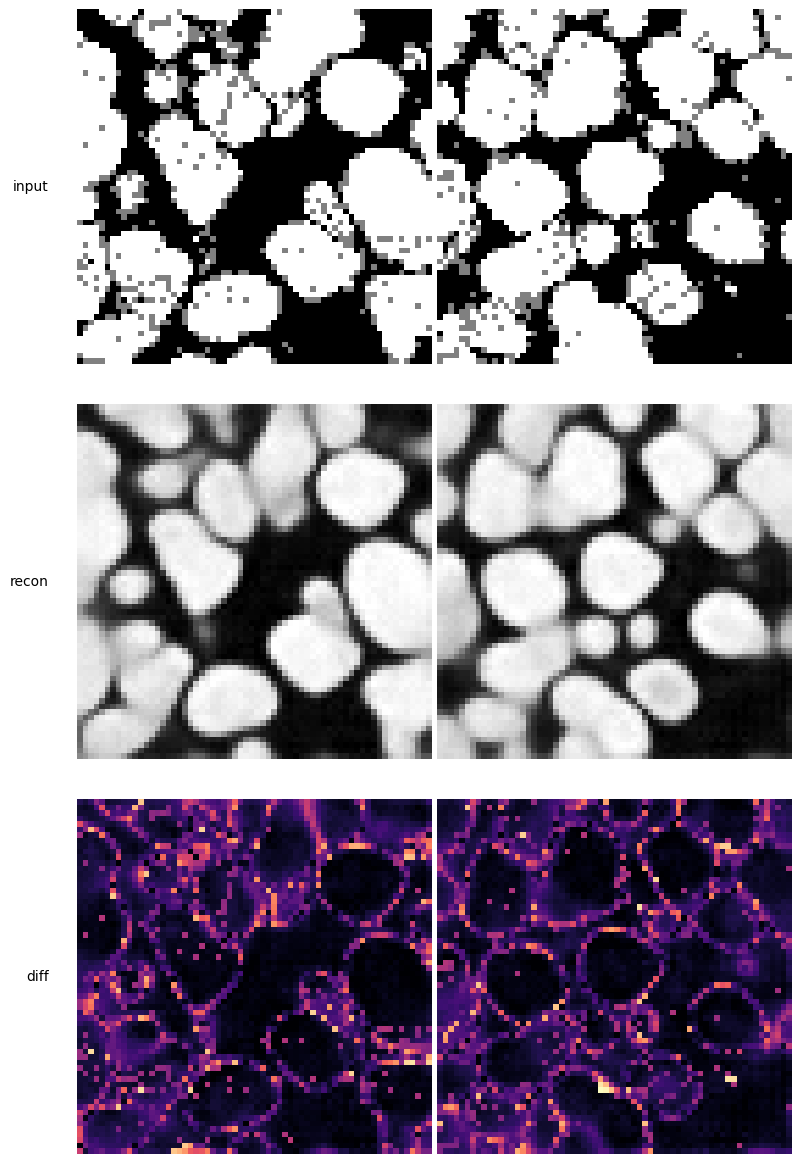

In [3]:
n = min(2, batch.shape[0])
rows = [("input", batch[:n, 0], "gray"), ("recon", recon[:n, 0], "gray"), ("diff", diff[:n, 0], "magma")]

fig, axes = plt.subplots(len(rows), n, figsize=(8, 12), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for r, (label, images, cmap) in enumerate(rows):
    axes[r, 0].text(-0.08, 0.5, label, transform=axes[r, 0].transAxes, ha="right", va="center")
    for c in range(n):
        axes[r, c].imshow(images[c], cmap=cmap, vmin=0 if label == "diff" else -1, vmax=float(diff.max()) if label == "diff" else 1, interpolation="nearest")
plt.tight_layout()